## Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Define timeframe for stock data

In [2]:
end = date.today()
# start = end.replace(
#     year = end.year - 6,
#     day = min(end.day, 28) if end.month == 2 else end.day
# )

# start_date = start.strftime("%Y-%m-%d")
start_date = "2020-01-01"
end_date = end.strftime("%Y-%m-%d")

## Fetch and clean stock data

In [3]:
ticker = "AAPL"

In [4]:
df = yf.download(ticker, start_date, end_date)
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
1,2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2,2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
3,2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


## Plot stock data

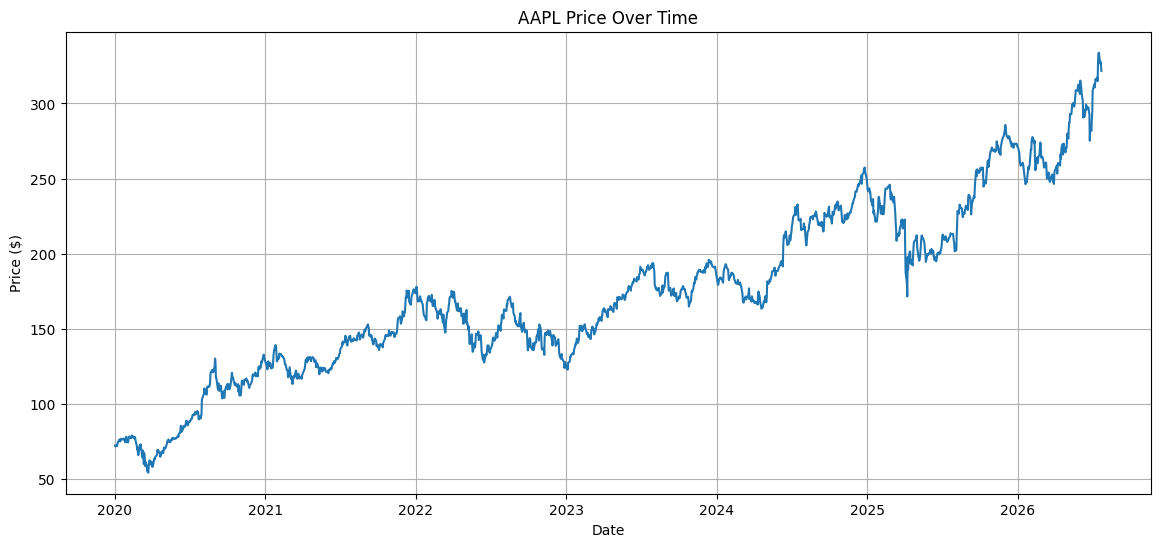

In [5]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title(f"{ticker} Price Over Time")
plt.show()

## Plot the 9, 21, and 100 EMAs

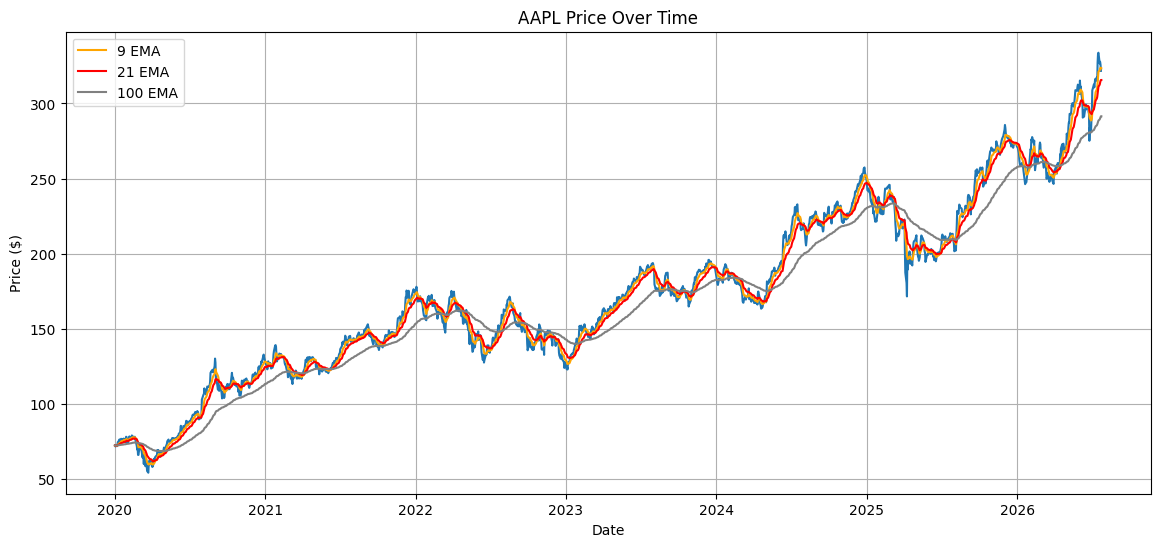

In [6]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title(f"{ticker} Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

## Create 21 EMA distance, 21 EMA slope, and daily % return features

In [7]:
df["dist_ema21"] = (df["Close"] - df["ema21"]) / df["ema21"]
df["slope_ema21"] = df["ema21"].diff()
df["return"] = df["Close"].pct_change()
df["volume_change"] = df["Volume"].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100,dist_ema21,slope_ema21,return,volume_change
0,2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400,72.333870,72.333870,72.333870,0.000000,NaN,NaN,NaN
1,2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,72.193225,72.269940,72.319945,-0.008846,-0.063929,-0.009722,0.080029
2,2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,72.194865,72.263712,72.317598,-0.000862,-0.006229,0.007968,-0.190918
3,2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,72.128263,72.227179,72.308573,-0.005058,-0.036532,-0.004703,-0.080374
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,72.306176,72.299057,72.322618,0.009942,0.071877,0.016086,0.213160


In [8]:
df = df.dropna().reset_index(drop=True)
df.drop(columns=["High", "Low", "Open", "Volume"], inplace=True)
df.head()

,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return,volume_change
0,2020-01-03,71.630646,72.193225,72.269940,72.319945,-0.008846,-0.063929,-0.009722,0.080029
1,2020-01-06,72.201424,72.194865,72.263712,72.317598,-0.000862,-0.006229,0.007968,-0.190918
2,2020-01-07,71.861855,72.128263,72.227179,72.308573,-0.005058,-0.036532,-0.004703,-0.080374
3,2020-01-08,73.017830,72.306176,72.299057,72.322618,0.009942,0.071877,0.016086,0.213160
4,2020-01-09,74.568802,72.758701,72.505397,72.367097,0.028459,0.206340,0.021241,0.287927


## Use a 70/15/15 train/validation/test split

In [9]:
df.shape

(1646, 9)

In [10]:
train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.85)

train = df[:train_end]
val = df[train_end:val_end]
test = df[val_end:]

In [11]:
print(train.shape)
train.head()

(1152, 9)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return,volume_change
0,2020-01-03,71.630646,72.193225,72.269940,72.319945,-0.008846,-0.063929,-0.009722,0.080029
1,2020-01-06,72.201424,72.194865,72.263712,72.317598,-0.000862,-0.006229,0.007968,-0.190918
2,2020-01-07,71.861855,72.128263,72.227179,72.308573,-0.005058,-0.036532,-0.004703,-0.080374
3,2020-01-08,73.017830,72.306176,72.299057,72.322618,0.009942,0.071877,0.016086,0.213160
4,2020-01-09,74.568802,72.758701,72.505397,72.367097,0.028459,0.206340,0.021241,0.287927


In [12]:
print(val.shape)
val.head()

(247, 9)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return,volume_change
1152,2024-08-02,217.971832,218.537556,218.701405,200.363032,-0.003336,-0.072957,0.006869,0.689071
1153,2024-08-05,207.472794,216.324604,217.680622,200.503820,-0.046894,-1.020783,-0.048167,0.132426
1154,2024-08-06,205.450302,214.149743,216.568775,200.601770,-0.051339,-1.111847,-0.009748,-0.417304
1155,2024-08-07,208.018066,212.923408,215.791438,200.748627,-0.036023,-0.777337,0.012498,-0.088201
1156,2024-08-08,211.478073,212.634341,215.399314,200.961091,-0.018205,-0.392124,0.016633,-0.257497


In [13]:
print(test.shape)
test.head()

(247, 9)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return,volume_change
1399,2025-07-30,208.223923,210.992718,209.534002,209.643278,-0.006252,-0.131008,-0.010508,-0.114744
1400,2025-07-31,206.749802,210.144135,209.280893,209.585981,-0.012094,-0.253109,-0.007079,0.773104
1401,2025-08-01,201.580292,208.431366,208.580838,209.427453,-0.033563,-0.700055,-0.025004,0.294133
1402,2025-08-04,202.546463,207.254386,208.032258,209.291196,-0.026370,-0.548580,0.004793,-0.280800
1403,2025-08-05,202.118149,206.227138,207.494612,209.149155,-0.025911,-0.537646,-0.002115,-0.412122


## Normalize the dataset

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
features = ["Close", "ema21", "dist_ema21", "slope_ema21", "return", "volume_change"]
target = "Close"

# MinMaxScaler has default param feature_range=(0,1)
features_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Training data
train_features = train[features]
train_target = train[[target]]

# Validation data
val_features = val[features]
val_target = val[[target]]

# Testing data
test_features = test[features]
test_target = test[[target]]

# Scale training data
train_features_scaled = features_scaler.fit_transform(train_features)
train_target_scaled = target_scaler.fit_transform(train_target)

window = 20

# Scale validation data
prev_window_val = train_features.tail(window)
val_features = pd.concat([prev_window_val, val_features], ignore_index=True)
val_features_scaled = features_scaler.transform(val_features)
val_target_scaled = target_scaler.transform(val_target)

# Scale testing data
# We take data from val_features (and not train_features) because data needs to stay chronological
prev_window_test = val_features.tail(window)
test_features = pd.concat([prev_window_test, test_features], ignore_index=True)
test_features_scaled = features_scaler.transform(test_features)
test_target_scaled = target_scaler.transform(test_target)

print(train_features_scaled.shape)
print(val_features_scaled.shape)
print(test_features_scaled.shape)

print(train_target_scaled.shape)
print(val_target_scaled.shape)
print(test_target_scaled.shape)

(1152, 6)
(267, 6)
(267, 6)
(1152, 1)
(247, 1)
(247, 1)


In [16]:
print(train_features_scaled[:3])
print(train_features_scaled[-3:])

[[0.09777747 0.06596432 0.5096369  0.42170579 0.47865772 0.22649527]
 [0.1009726  0.06592506 0.53642263 0.43840004 0.54985879 0.14425188]
 [0.09907174 0.06569475 0.52234518 0.42963243 0.49885791 0.17780649]]
[[0.91109236 0.9902711  0.50918955 0.38333708 0.52811525 0.24677483]
 [0.92929557 0.99100834 0.5572291  0.4740368  0.57812321 0.26337586]
 [0.90865038 0.98956489 0.50420229 0.37395683 0.45036776 0.27781909]]


In [17]:
print(test_features_scaled[:3])
print(test_features_scaled[-3:])

[[0.85554946 0.8772018  0.64028431 0.61518028 0.56977289 0.15886165]
 [0.88130956 0.88330522 0.7001739  0.72031037 0.60726387 0.1604138 ]
 [0.88749851 0.88948741 0.70146252 0.72392555 0.53881674 0.05483301]]
[[1.53144197 1.58917967 0.68737856 0.84099979 0.53195965 0.1333456 ]
 [1.52108606 1.59605868 0.65553853 0.75590507 0.49506824 0.18323685]
 [1.49740705 1.59988805 0.60388888 0.61594589 0.46554489 0.21853231]]


In [18]:
print(train_target_scaled[:3])
print(train_target_scaled[-3:])

[[0.09777747]
 [0.1009726 ]
 [0.09907174]]
[[0.91109236]
 [0.92929557]
 [0.90865038]]


In [19]:
print(test_target_scaled[:3])
print(test_target_scaled[-3:])

[[0.86240764]
 [0.85415572]
 [0.82521752]]
[[1.53144197]
 [1.52108606]
 [1.49740705]]


## Create training sequences

In [20]:
x_train = []
y_train = []

# For each timestamp (row) x, grab the #(window) timestamps before it and add them as a singular element to x_train. Add timestamp x as an element to y_train.
for i in range(window, train_features_scaled.shape[0]):
    x_train.append(train_features_scaled[i - window : i])
    y_train.append(train_target_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(1132, 20, 6)
(1132,)


## Create validation sequences

In [21]:
x_val = []
y_val = []

for i in range(window, val_features_scaled.shape[0]):
    x_val.append(val_features_scaled[i - window : i])
    y_val.append(val_target_scaled[i - window, 0])

x_val = np.array(x_val)
y_val = np.array(y_val)

print(x_val.shape)
print(y_val.shape)

(247, 20, 6)
(247,)


## Create testing sequences

In [22]:
x_test = []
y_test = []

for i in range(window, test_features_scaled.shape[0]):
    x_test.append(test_features_scaled[i - window : i])
    y_test.append(test_target_scaled[i - window, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(247, 20, 6)
(247,)


## Build LSTM model

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

tf.keras.utils.set_random_seed(22)

In [24]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=32))
model.add(Dropout(0.1))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

early_stopping = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val), shuffle=False, callbacks=[early_stopping])

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0137 - mean_absolute_error: 0.0957 - val_loss: 0.0098 - val_mean_absolute_error: 0.0845
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0330 - mean_absolute_error: 0.1436 - val_loss: 0.0182 - val_mean_absolute_error: 0.1245
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0092 - mean_absolute_error: 0.0763 - val_loss: 0.0029 - val_mean_absolute_error: 0.0422
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - mean_absolute_error: 0.0518 - val_loss: 0.0024 - val_mean_absolute_error: 0.0379
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042 - mean_absolute_error: 0.0511 - val_loss: 0.0020 - val_mean_absolute_error: 0.0331
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - mean_absolute_error: 0.0516 - val_loss: 0.0024 - val_mean_absolute_error: 0.0351
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - mean_absolute_error: 0.0538 - val_los

## Baseline MAE and RMSE benchmarks on validation set (to beat)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [28]:
val_actual = val["Close"].to_numpy()

val_baseline = np.r_[
    train["Close"].iloc[-1],
    val_actual[:-1]
]

baseline_mae = mean_absolute_error(val_actual, val_baseline)
baseline_rmse = np.sqrt(mean_squared_error(val_actual, val_baseline))

print(f"Baseline validation MAE: ${baseline_mae:.4f}")
print(f"Baseline validation RMSE: ${baseline_rmse:.4f}")

Baseline validation MAE: $2.7193
Baseline validation RMSE: $4.1261


## LSTM MAE and RMSE benchmarks on validation set

In [29]:
val_pred = model.predict(x_val, verbose=0)

val_pred_prices = target_scaler.inverse_transform(val_pred).flatten()
val_actual_prices = target_scaler.inverse_transform(
    y_val.reshape(-1, 1)
).flatten()

lstm_val_mae = mean_absolute_error(val_actual_prices, val_pred_prices)
lstm_val_rmse = np.sqrt(
    mean_squared_error(val_actual_prices, val_pred_prices)
)

print(f"LSTM validation MAE: ${lstm_val_mae:.4f}")
print(f"LSTM validation RMSE: ${lstm_val_rmse:.4f}")

LSTM validation MAE: $3.2725
LSTM validation RMSE: $4.4935


## Plot loss curves

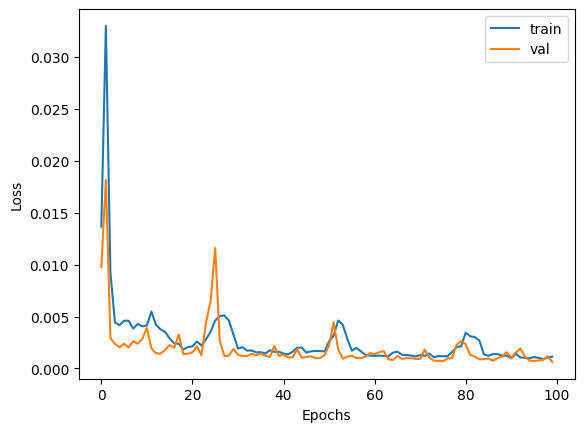

In [30]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## Make prediction

In [31]:
y_pred = model.predict(x_test)
print(y_pred.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
(247, 1)


In [32]:
print(y_test[:10])

[0.86240764 0.85415572 0.82521752 0.83062601 0.82822837 0.88582579
 0.92362929 0.97559529 0.96493342 0.97872111]


In [33]:
print(y_pred[:10])

[[0.8777912 ]
 [0.86695725]
 [0.853828  ]
 [0.82944256]
 [0.82942206]
 [0.8294017 ]
 [0.8666757 ]
 [0.90494066]
 [0.9565179 ]
 [0.9578418 ]]


## Plot prediction

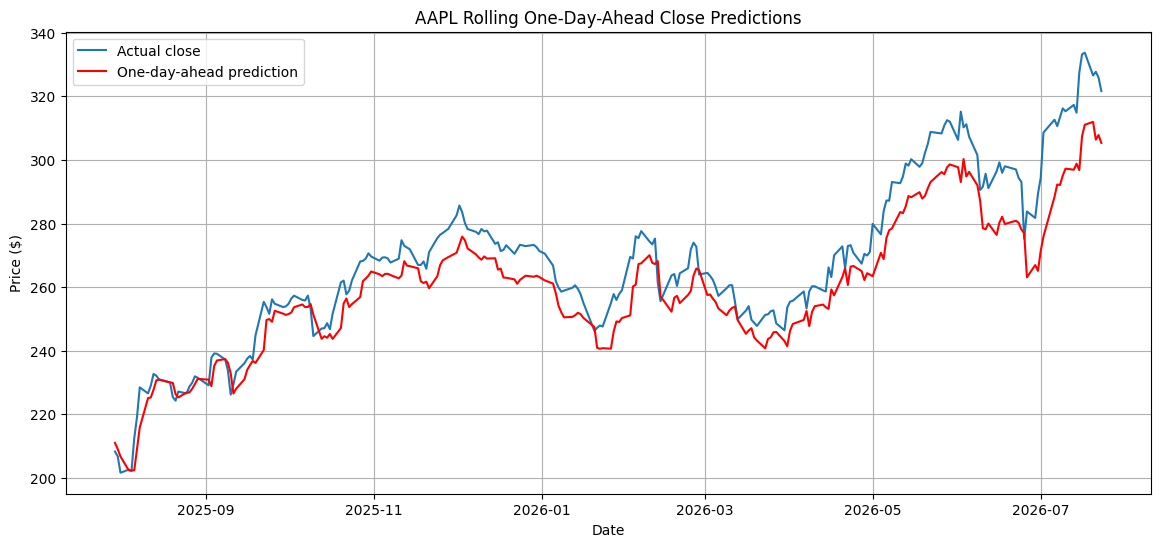

In [34]:
y_pred_prices = target_scaler.inverse_transform(y_pred).flatten()
y_test_prices = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual close")
plt.plot(test["Date"], y_pred_prices, label="One-day-ahead prediction", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title(f"{ticker} Rolling One-Day-Ahead Close Predictions")
plt.legend()

## Model evaluation

In [35]:
mae = mean_absolute_error(y_test_prices, y_pred_prices)
print(f"MAE: ${mae:.4f}")

MAE: $8.3707


In [36]:
rmse = np.sqrt(mean_squared_error(y_test_prices, y_pred_prices))
print(f"RMSE: ${rmse:.4f}")

RMSE: $10.2113


In [37]:
mape = np.mean(np.abs((y_test_prices - y_pred_prices) / y_test_prices)) * 100
print(f"MAPE: {mape:.4f}%")

MAPE: 3.0106%


## Directional Accuracy

In [38]:
prev_close = np.r_[
    val["Close"].iloc[-1],
    test["Close"].iloc[:-1].to_numpy()
]

assert len(prev_close) == len(y_test_prices) == len(y_pred_prices)

actual_up = y_test_prices > prev_close
predicted_up = y_pred_prices > prev_close

direction = np.mean(actual_up == predicted_up) * 100
print(f"Directional accuracy: {direction:.4f}%")

Directional accuracy: 48.1781%
